# Pragma injection audit

Post-graph inspection of injected Vitis pragmas. This notebook reads existing graph JSON files only. It does not compile, regraph, tensorize datasets, or modify artifacts.

It answers four questions: what was injected, which arguments are retained versus encoded by the current tensor schema, how pragmas are anchored, and which attachments need manual review.

In [1]:
from collections import Counter, defaultdict
import json
import math
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

cwd = Path.cwd().resolve()
REPO_ROOT = next(
    path for path in (cwd, cwd.parent, cwd / 'll-hls4ml')
    if (path / 'src' / 'll_hls4ml').is_dir()
)
sys.path.insert(0, str(REPO_ROOT / 'src'))

from ll_hls4ml.data.tensorize import pragma_embedding
from ll_hls4ml.io.schema import (
    FLOW_BLOCK,
    FLOW_PRAGMA,
    NODE_BLOCK,
    NODE_PRAGMA,
    NODE_TYPES,
    PRAGMA_ARGUMENT_DIRECTIVES,
    PRAGMA_CATEGORICAL_ARGUMENTS,
    PRAGMA_NUMERIC_ARGUMENTS,
    PRAGMA_SCHEMA_VERSION,
    PRAGMA_TARGET_ARGUMENTS,
    PRAGMA_VOCAB,
)

GRAPH_ROOT = Path(os.environ.get(
    'LL_HLS4ML_GRAPH_ROOT', REPO_ROOT.parent / 'data' / 'graphs'
)).resolve()

# Set either filter to a collection of names, or leave as None for everything.
KERNEL_FILTER = ['2layer', 'conv1d', 'exemplar']
ARCHIVE_FILTER = ['archive_1']      # e.g. {'archive_1', 'archive_4'}
MAX_GRAPHS = None          # e.g. 100 for a quick sampled audit

print(f'Repository: {REPO_ROOT}')
print(f'Graph root: {GRAPH_ROOT}')

Repository: /home/brend/projects/ll-hls4ml
Graph root: /home/brend/projects/data/graphs


## Current learned schema

Every known pragma directive has a categorical ID. Only the directives listed below receive argument features. Numeric fields use a value plus a presence mask; categorical fields use explicit named slots. Target names are deliberately omitted from node features because `pragma → target` edges represent them structurally. Everything else remains losslessly available in graph JSON but is not consumed by the model.

In [2]:
display(pd.DataFrame({
    'directive': sorted(PRAGMA_VOCAB, key=PRAGMA_VOCAB.get),
    'directive_id': [PRAGMA_VOCAB[key] for key in sorted(PRAGMA_VOCAB, key=PRAGMA_VOCAB.get)],
    'arguments_encoded': [key in PRAGMA_ARGUMENT_DIRECTIVES for key in sorted(PRAGMA_VOCAB, key=PRAGMA_VOCAB.get)],
}))
display(pd.DataFrame({'numeric_argument': PRAGMA_NUMERIC_ARGUMENTS}))
display(pd.DataFrame(PRAGMA_CATEGORICAL_ARGUMENTS, columns=['argument', 'encoded_value']))

,directive,directive_id,arguments_encoded
0,UNK,0,False
1,pragma.allocation,1,True
2,pragma.array_partition,2,True
3,pragma.array_reshape,3,True
4,pragma.dataflow,4,True
5,pragma.function_instantiate,5,False
6,pragma.inline,6,True
7,pragma.interface,7,True
8,pragma.pipeline,8,True
9,pragma.unroll,9,True


,numeric_argument
0,ii
1,factor
2,dim
3,depth
4,min
5,max
6,avg
7,latency
8,interval
9,num


,argument,encoded_value
0,complete,true
1,block,true
2,cyclic,true
3,rewind,true
4,enable_flush,true
5,disable_start_propagation,true
6,off,true
7,recursive,true
8,skip_exit_check,true
9,force,true


In [3]:
def graph_paths(root=GRAPH_ROOT):
    paths = []
    for kernel_dir in sorted(root.iterdir() if root.is_dir() else []):
        if not kernel_dir.is_dir() or (KERNEL_FILTER and kernel_dir.name not in KERNEL_FILTER):
            continue
        for archive_dir in sorted(kernel_dir.glob('archive_*')):
            if ARCHIVE_FILTER and archive_dir.name not in ARCHIVE_FILTER:
                continue
            paths.extend(sorted(archive_dir.glob('*.json')))
    return paths[:MAX_GRAPHS] if MAX_GRAPHS else paths


def feature_value(node, key, default=''):
    value = node.get('features', {}).get(key, [default])
    return value[0] if isinstance(value, list) and value else value


def pragma_arguments(node):
    raw = feature_value(node, 'arguments_json', '{}')
    try:
        value = json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        return {}
    return value if isinstance(value, dict) else {}


def full_text(node):
    value = node.get('features', {}).get('full_text', [])
    return '\n'.join(map(str, value)) if isinstance(value, list) else str(value)


def pragma_text(node):
    stored = feature_value(node, 'pragma_text', '')
    if stored:
        return str(stored)
    return full_text(node)


def argument_coverage(node):
    directive = node.get('text', 'pragma.unknown')
    arguments = pragma_arguments(node)
    encoded, retained, structural = [], [], []
    if directive not in PRAGMA_ARGUMENT_DIRECTIVES:
        retained = [f'{key}={value}' for key, values in arguments.items() for value in values]
        return 'directive_only', encoded, retained, structural

    numeric = set(PRAGMA_NUMERIC_ARGUMENTS)
    categorical = set(PRAGMA_CATEGORICAL_ARGUMENTS)
    for key, values in arguments.items():
        for raw_value in values:
            value = str(raw_value)
            token = f'{key}={value}'
            if key in PRAGMA_TARGET_ARGUMENTS:
                structural.append(token)
                continue
            try:
                number = float(value)
                is_number = math.isfinite(number)
            except (TypeError, ValueError):
                is_number = False
            if key in numeric and is_number:
                encoded.append(token)
            elif (key, value.lower()) in categorical:
                encoded.append(token)
            else:
                retained.append(token)
    state = 'arguments_encoded' if encoded else 'selected_no_encoded_arguments'
    return state, encoded, retained, structural


def attachment_assessment(node, targets):
    reason = str(feature_value(node, 'anchor_reason', 'unknown'))
    target_names = [name for name in str(feature_value(node, 'target_names', '')).split(',') if name]
    target_types = {int(target.get('type', -1)) for target in targets}
    matched_names = {
        name for name in target_names
        if any(f'%{name}' in full_text(target) for target in targets)
    }
    if not targets:
        return 'missing', matched_names
    if reason == 'source_loop_label' and 4 in target_types:
        return 'exact_loop_block', matched_names
    if reason in {'carrier_exact', 'carrier_only'} and 0 in target_types:
        return 'precise_carrier', matched_names
    if reason == 'variable_identity' and (not target_names or matched_names):
        return 'named_target', matched_names
    if reason == 'function_scope_entry' and 0 in target_types:
        return 'function_fallback', matched_names
    if reason == 'function_scope_entry_block' and 4 in target_types:
        return 'function_entry_block', matched_names
    return 'review', matched_names


def audit_graphs(paths):
    graph_rows, pragma_rows, unmatched_rows = [], [], []
    for index, path in enumerate(paths, 1):
        relative = path.relative_to(GRAPH_ROOT).as_posix()
        try:
            graph = json.loads(path.read_text())
        except Exception as exc:
            graph_rows.append({'graph': relative, 'error': str(exc), 'pragma_nodes': 0, 'unmatched': 0})
            continue
        nodes = graph.get('nodes', [])
        node_by_id = {int(node['id']): node for node in nodes}
        pragma_links = defaultdict(list)
        for link in graph.get('links', []):
            if int(link.get('flow', -1)) == FLOW_PRAGMA:
                pragma_links[int(link['source'])].append(int(link['target']))
        pragmas = [node for node in nodes if int(node.get('type', -1)) == NODE_PRAGMA]
        unmatched = graph.get('pragma_injection', {}).get('unmatched_records', [])
        graph_rows.append({
            'graph': relative,
            'kernel': path.parents[1].name,
            'archive': path.parent.name,
            'nodes': len(nodes),
            'pragma_nodes': len(pragmas),
            'unmatched': len(unmatched),
            'error': '',
        })
        for record in unmatched:
            unmatched_rows.append({'graph': relative, **record})
        for node in pragmas:
            target_ids = pragma_links.get(int(node['id']), [])
            targets = [node_by_id[target] for target in target_ids if target in node_by_id]
            coverage, encoded, retained, structural = argument_coverage(node)
            attachment, matched_names = attachment_assessment(node, targets)
            pragma_rows.append({
                'graph': relative,
                'kernel': path.parents[1].name,
                'archive': path.parent.name,
                'pragma_id': int(node['id']),
                'directive': node.get('text', 'pragma.unknown'),
                'pragma_text': pragma_text(node),
                'known_directive': node.get('text') in PRAGMA_VOCAB,
                'schema_version': feature_value(node, 'schema_version', ''),
                'origin': feature_value(node, 'origin', ''),
                'anchor_reason': feature_value(node, 'anchor_reason', ''),
                'attachment': attachment,
                'target_count': len(targets),
                'target_ids': target_ids,
                'target_types': sorted({NODE_TYPES[int(t.get('type', -1))] if 0 <= int(t.get('type', -1)) < len(NODE_TYPES) else 'unknown' for t in targets}),
                'target_names': feature_value(node, 'target_names', ''),
                'matched_target_names': sorted(matched_names),
                'coverage': coverage,
                'encoded_arguments': encoded,
                'retained_only_arguments': retained,
                'structural_arguments': structural,
                'raw_options': feature_value(node, 'raw_options', ''),
            })
        if index % 100 == 0:
            print(f'Audited {index}/{len(paths)} graphs')
    return pd.DataFrame(graph_rows), pd.DataFrame(pragma_rows), pd.DataFrame(unmatched_rows)


## Dataset-wide audit

In [4]:
paths = graph_paths()
print(f'Discovered {len(paths):,} graph JSON files')
graph_audit, pragma_audit, unmatched_audit = audit_graphs(paths)

overview = pd.Series({
    'graphs': len(graph_audit),
    'graphs with pragmas': int((graph_audit.get('pragma_nodes', pd.Series(dtype=int)) > 0).sum()),
    'injected pragma nodes': int(graph_audit.get('pragma_nodes', pd.Series(dtype=int)).sum()),
    'unmatched dump records': int(graph_audit.get('unmatched', pd.Series(dtype=int)).sum()),
    'graphs with read errors': int(graph_audit.get('error', pd.Series(dtype=str)).astype(bool).sum()),
})
display(overview.to_frame('count'))
if not graph_audit.empty and {'kernel', 'archive'} <= set(graph_audit.columns):
    display(graph_audit.groupby(['kernel', 'archive'], dropna=False)[['pragma_nodes', 'unmatched']].agg(['count', 'sum', 'mean']))

Discovered 249 graph JSON files
Audited 100/249 graphs
Audited 200/249 graphs


,count
graphs,249
graphs with pragmas,249
injected pragma nodes,12534
unmatched dump records,34659
graphs with read errors,0


pragma_nodes                   unmatched                   
                          count   sum        mean     count    sum        mean
kernel   archive                                                              
2layer   archive_1          100  1900   19.000000       100   5400   54.000000
conv1d   archive_1           49  5484  111.918367        49  13624  278.040816
exemplar archive_1          100  5150   51.500000       100  15635  156.350000

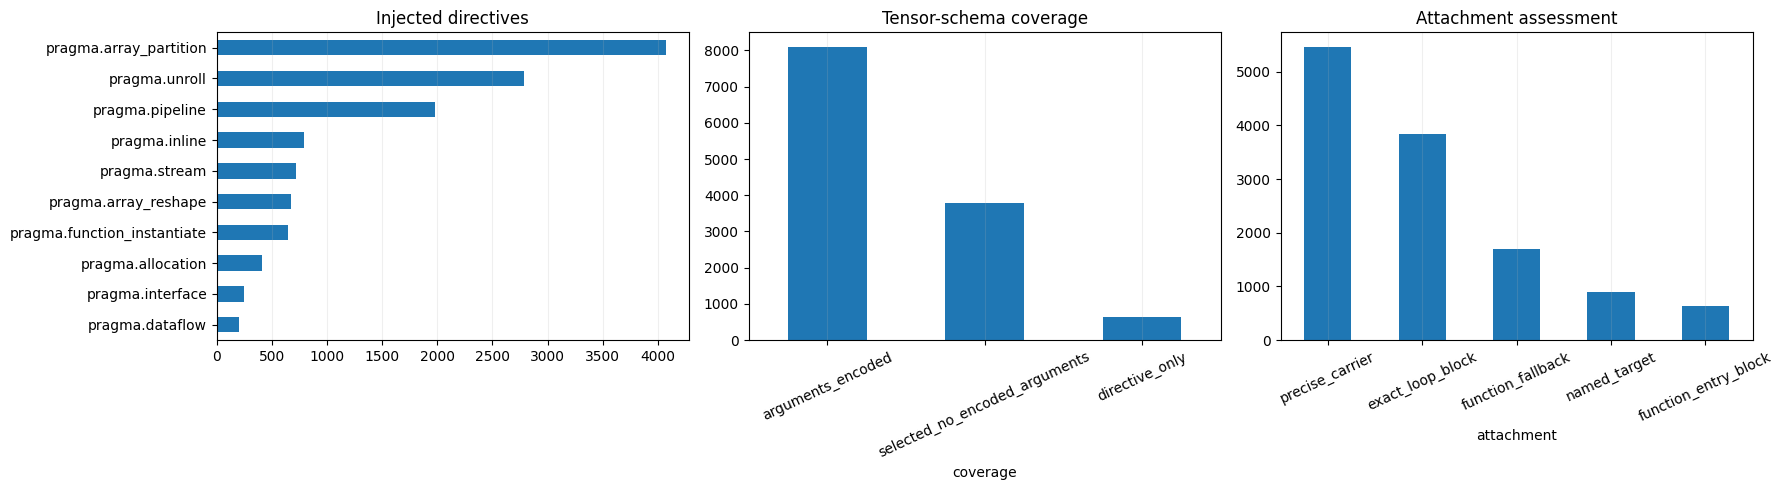

coverage,arguments_encoded,directive_only,selected_no_encoded_arguments
directive,,,
pragma.allocation,412,0,0
pragma.array_partition,4022,0,54
pragma.array_reshape,669,0,0
pragma.dataflow,0,0,206
pragma.function_instantiate,0,647,0
pragma.inline,794,0,0
pragma.interface,249,0,0
pragma.pipeline,1234,0,748
pragma.stream,715,0,0


anchor_reason,carrier_exact,carrier_only,function_scope_entry,function_scope_entry_block,source_loop_label,variable_identity
directive,,,,,,
pragma.allocation,0,0,178,234,0,0
pragma.array_partition,4022,54,0,0,0,0
pragma.array_reshape,669,0,0,0,0,0
pragma.dataflow,0,0,157,49,0,0
pragma.function_instantiate,0,0,0,0,0,647
pragma.inline,0,0,435,359,0,0
pragma.interface,0,0,0,0,0,249
pragma.pipeline,0,0,704,0,1278,0
pragma.stream,715,0,0,0,0,0


In [5]:
if pragma_audit.empty:
    print('No injected pragma nodes found.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pragma_audit['directive'].value_counts().sort_values().plot.barh(ax=axes[0], title='Injected directives')
    pragma_audit['coverage'].value_counts().plot.bar(ax=axes[1], title='Tensor-schema coverage', rot=25)
    pragma_audit['attachment'].value_counts().plot.bar(ax=axes[2], title='Attachment assessment', rot=25)
    for axis in axes:
        axis.set_ylabel('')
        axis.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

    display(pd.crosstab(pragma_audit['directive'], pragma_audit['coverage']))
    display(pd.crosstab(pragma_audit['directive'], pragma_audit['anchor_reason']))

## Argument coverage

`encoded` means the current tensorizer consumes the argument. `structural` means it is a target represented by pragma edges. `retained_only` means it survives in JSON and the pragma dump but currently contributes no learned feature.

In [6]:
argument_rows = []
for row in pragma_audit.itertuples(index=False):
    for status, values in (
        ('encoded', row.encoded_arguments),
        ('structural', row.structural_arguments),
        ('retained_only', row.retained_only_arguments),
    ):
        for token in values:
            key, _, value = token.partition('=')
            argument_rows.append({
                'directive': row.directive,
                'argument': key,
                'value': value,
                'status': status,
                'graph': row.graph,
            })
argument_audit = pd.DataFrame(argument_rows)

if argument_audit.empty:
    print('No pragma arguments found.')
else:
    argument_summary = (
        argument_audit.groupby(['directive', 'argument', 'status'])
        .size().rename('count').reset_index()
        .sort_values(['status', 'count'], ascending=[True, False])
    )
    display(argument_summary)
    print('Most common retained-only values:')
    display(
        argument_audit[argument_audit['status'] == 'retained_only']
        .groupby(['directive', 'argument', 'value']).size()
        .rename('count').sort_values(ascending=False).head(50).reset_index()
    )

,directive,argument,status,count
7,pragma.array_partition,complete,encoded,4022
8,pragma.array_partition,dim,encoded,1293
24,pragma.pipeline,ii,encoded,1234
27,pragma.stream,depth,encoded,715
25,pragma.pipeline,rewind,encoded,669
20,pragma.inline,recursive,encoded,643
13,pragma.array_reshape,block,encoded,469
16,pragma.array_reshape,factor,encoded,469
1,pragma.allocation,limit,encoded,412
14,pragma.array_reshape,complete,encoded,200


Most common retained-only values:


,directive,argument,value,count
0,pragma.array_partition,_carrier_arg_2,0,4076
1,pragma.array_partition,_carrier_arg_1,2,4076
2,pragma.array_partition,_carrier_arg_4,false,4076
3,pragma.array_partition,_carrier_arg_3,1,2783
4,pragma.array_partition,_carrier_arg_3,0,1293
5,pragma.function_instantiate,variable,"weights,biases",647
6,pragma.array_reshape,_carrier_arg_3,1,469
7,pragma.array_reshape,_carrier_arg_1,1,469
8,pragma.allocation,operation,true,412
9,pragma.allocation,instances,mul,412


## Numeric argument distributions

Check whether learned numeric pragma arguments actually vary across the currently selected graphs. `constant` means the field cannot distinguish samples in this selection; `concentrated` means at least 90% of occurrences share one value; `varied` means no single value reaches 90%. Counts are pragma-node occurrences, matching what the model receives.

In [7]:
numeric_argument_audit = argument_audit[
    argument_audit['argument'].isin(PRAGMA_NUMERIC_ARGUMENTS)
].copy()

if numeric_argument_audit.empty:
    print('No numeric pragma arguments found.')
else:
    numeric_argument_audit['numeric_value'] = pd.to_numeric(
        numeric_argument_audit['value'], errors='coerce'
    )
    invalid = numeric_argument_audit[
        ~np.isfinite(numeric_argument_audit['numeric_value'])
    ]
    if not invalid.empty:
        raise ValueError(
            'Non-numeric values remain in numeric pragma arguments:\n'
            + invalid[['graph', 'directive', 'argument', 'value']]
            .head(20).to_string(index=False)
        )

    numeric_argument_audit['kernel'] = (
        numeric_argument_audit['graph'].str.split('/').str[0]
    )
    group_columns = ['kernel', 'directive', 'argument']
    distributions = (
        numeric_argument_audit.groupby(group_columns)
        .agg(
            count=('numeric_value', 'size'),
            graphs=('graph', 'nunique'),
            unique_values=('numeric_value', 'nunique'),
            minimum=('numeric_value', 'min'),
            q25=('numeric_value', lambda values: values.quantile(0.25)),
            median=('numeric_value', 'median'),
            q75=('numeric_value', lambda values: values.quantile(0.75)),
            maximum=('numeric_value', 'max'),
        )
        .reset_index()
    )
    value_counts = (
        numeric_argument_audit.groupby(group_columns + ['numeric_value'])
        .size().rename('value_count').reset_index()
        .sort_values(group_columns + ['value_count'], ascending=[True, True, True, False])
    )
    value_counts['rank'] = value_counts.groupby(group_columns).cumcount() + 1
    top_values = value_counts[value_counts['rank'] == 1].rename(
        columns={'numeric_value': 'top_value'}
    )
    distributions = distributions.merge(
        top_values[group_columns + ['top_value', 'value_count']],
        on=group_columns,
    )
    distributions['top_share'] = (
        distributions['value_count'] / distributions['count']
    )
    distributions['variation'] = np.select(
        [
            distributions['unique_values'] == 1,
            distributions['top_share'] >= 0.9,
        ],
        ['constant', 'concentrated'],
        default='varied',
    )
    display(distributions.drop(columns='value_count'))

    print('Ten most common values per directive/argument:')
    display(value_counts[value_counts['rank'] <= 10])

,kernel,directive,argument,count,graphs,unique_values,minimum,q25,median,q75,maximum,top_value,top_share,variation
0,2layer,pragma.array_partition,dim,200,100,1,0,0.0,0.0,0.0,0,0,1.000000,constant
1,2layer,pragma.array_reshape,dim,100,100,1,0,0.0,0.0,0.0,0,0,1.000000,constant
2,2layer,pragma.pipeline,ii,200,100,1,1,1.0,1.0,1.0,1,1,1.000000,constant
3,conv1d,pragma.allocation,limit,234,49,1,1,1.0,1.0,1.0,1,1,1.000000,constant
4,conv1d,pragma.array_partition,dim,197,49,1,0,0.0,0.0,0.0,0,0,1.000000,constant
5,conv1d,pragma.array_reshape,factor,234,49,2,1,1.0,1.0,1.0,4,1,0.995726,concentrated
6,conv1d,pragma.pipeline,ii,621,49,98,1,1.0,48.0,256.0,8192,1,0.376812,varied
7,conv1d,pragma.stream,depth,715,49,59,1,2.0,14.0,34.0,133,1,0.247552,varied
8,exemplar,pragma.allocation,limit,178,43,20,1,2.0,11.0,320.0,2048,1,0.213483,varied
9,exemplar,pragma.array_partition,dim,896,100,1,0,0.0,0.0,0.0,0,0,1.000000,constant


Ten most common values per directive/argument:


,kernel,directive,argument,numeric_value,value_count,rank
0,2layer,pragma.array_partition,dim,0,200,1
1,2layer,pragma.array_reshape,dim,0,100,1
2,2layer,pragma.pipeline,ii,1,200,1
3,conv1d,pragma.allocation,limit,1,234,1
4,conv1d,pragma.array_partition,dim,0,197,1
5,conv1d,pragma.array_reshape,factor,1,233,1
6,conv1d,pragma.array_reshape,factor,4,1,2
7,conv1d,pragma.pipeline,ii,1,234,1
12,conv1d,pragma.pipeline,ii,32,42,2
17,conv1d,pragma.pipeline,ii,64,39,3


## Unmatched compiler records and attachments

Unmatched records commonly come from pragmas in included template headers whose functions were not instantiated in the final CDFG. They are retained for audit but intentionally not injected as model nodes. Review unusually high unmatched counts and every `missing` or `review` attachment.

In [8]:
if unmatched_audit.empty:
    print('No unmatched compiler records.')
else:
    display(
        unmatched_audit.groupby(['directive', 'function']).size()
        .rename('count').sort_values(ascending=False).head(100).reset_index()
    )

review_columns = [
    'graph', 'pragma_id', 'directive', 'pragma_text', 'anchor_reason', 'attachment',
    'target_count', 'target_types', 'target_names', 'matched_target_names',
    'raw_options',
]
if pragma_audit.empty:
    print('No injected attachments to review.')
else:
    display(
        pragma_audit[pragma_audit['attachment'].isin(['missing', 'review'])][review_columns]
        .sort_values(['attachment', 'directive', 'graph'])
    )

,directive,function,count
0,inline,product,1494
1,unroll,dense_resource_rf_gt_nin,1494
2,unroll,dense_compressed,996
3,array_partition,dense_resource_rf_gt_nin,996
4,unroll,softmax_stable,827
...,...,...,...
95,pipeline,global_pooling2d_cl,102
96,unroll,global_pooling1d_cl,102
97,pipeline,global_pooling1d_cl,102
98,unroll,global_pooling2d_cl,102


,graph,pragma_id,directive,pragma_text,anchor_reason,attachment,target_count,target_types,target_names,matched_target_names,raw_options


## Interactive attachment inspector

Select a graph and pragma to inspect its features, direct targets, and a bounded mini-graph spanning nearby LLVM blocks, instructions, data nodes, and other local pragmas. Red outlines mark the selected pragma and its direct anchors; truncation is reported explicitly.

In [9]:
def decoded_tensor_features(node):
    vector = pragma_embedding(node)
    decoded = [{'feature': 'directive_id', 'value': int(vector[0])}]
    numeric_offset = 1
    mask_offset = 1 + len(PRAGMA_NUMERIC_ARGUMENTS)
    categorical_offset = 1 + 2 * len(PRAGMA_NUMERIC_ARGUMENTS)
    for index, key in enumerate(PRAGMA_NUMERIC_ARGUMENTS):
        if vector[mask_offset + index]:
            decoded.append({'feature': key, 'value': float(vector[numeric_offset + index])})
    for index, (key, value) in enumerate(PRAGMA_CATEGORICAL_ARGUMENTS):
        if vector[categorical_offset + index]:
            decoded.append({'feature': f'{key}={value}', 'value': 1.0})
    return pd.DataFrame(decoded)


BLOCK_HOPS = 2
MAX_CONTEXT_BLOCKS = 9
MAX_INSTRUCTIONS_PER_BLOCK = 8
MAX_DATA_NODES = 30
MAX_LOCAL_PRAGMAS = 20


def short_text(value, width=46):
    value = ' '.join(str(value).split())
    return value if len(value) <= width else value[:width - 1] + '…'


def block_context(node_by_id, links, selected_pragma_id, targets):
    block_nodes = {
        node_id: node for node_id, node in node_by_id.items()
        if int(node.get('type', -1)) == NODE_BLOCK
    }
    block_by_location = {
        (int(node.get('function', -1)), int(node.get('block', -1))): node_id
        for node_id, node in block_nodes.items()
    }
    center_blocks = set()
    for target in targets:
        target_id = int(target['id'])
        if int(target.get('type', -1)) == NODE_BLOCK:
            center_blocks.add(target_id)
        else:
            block_id = block_by_location.get((
                int(target.get('function', -1)), int(target.get('block', -1))
            ))
            if block_id is not None:
                center_blocks.add(block_id)

    predecessors, successors = defaultdict(set), defaultdict(set)
    for link in links:
        source, target = int(link['source']), int(link['target'])
        if (
            int(link.get('flow', -1)) == FLOW_BLOCK
            and source in block_nodes and target in block_nodes
        ):
            successors[source].add(target)
            predecessors[target].add(source)

    selected_blocks = set(center_blocks)
    candidates = []
    for direction, adjacency in (('pre', predecessors), ('post', successors)):
        frontier = set(center_blocks)
        visited = set(center_blocks)
        for distance in range(1, BLOCK_HOPS + 1):
            frontier = {
                neighbor for node_id in frontier for neighbor in adjacency[node_id]
                if neighbor not in visited
            }
            visited.update(frontier)
            candidates.extend((distance, direction, node_id) for node_id in frontier)
    for _, _, node_id in sorted(candidates):
        if len(selected_blocks) >= max(MAX_CONTEXT_BLOCKS, len(center_blocks)):
            break
        selected_blocks.add(node_id)

    members = defaultdict(list)
    for link in links:
        source, target = int(link['source']), int(link['target'])
        if (
            int(link.get('flow', -1)) == FLOW_BLOCK
            and source in selected_blocks
            and int(node_by_id.get(target, {}).get('type', -1)) == 0
        ):
            members[source].append(target)

    direct_target_ids = {int(target['id']) for target in targets}
    shown_instructions, omitted_instructions = set(), 0
    for block_id in selected_blocks:
        ordered = sorted(set(members[block_id]))
        required = [node_id for node_id in ordered if node_id in direct_target_ids]
        chosen = list(dict.fromkeys(required + ordered[:MAX_INSTRUCTIONS_PER_BLOCK - 1]))
        if ordered:
            chosen.append(ordered[-1])
        chosen = list(dict.fromkeys(chosen))[:MAX_INSTRUCTIONS_PER_BLOCK]
        shown_instructions.update(chosen)
        omitted_instructions += max(0, len(ordered) - len(chosen))

    data_candidates = set()
    for link in links:
        if int(link.get('flow', -1)) != 1:
            continue
        source, target = int(link['source']), int(link['target'])
        if source in shown_instructions and int(node_by_id[target].get('type', -1)) in (1, 2):
            data_candidates.add(target)
        if target in shown_instructions and int(node_by_id[source].get('type', -1)) in (1, 2):
            data_candidates.add(source)
    prioritized_data = sorted(data_candidates, key=lambda node_id: (node_id not in direct_target_ids, node_id))
    shown_data = set(prioritized_data[:MAX_DATA_NODES]) | {
        node_id for node_id in direct_target_ids
        if int(node_by_id[node_id].get('type', -1)) in (1, 2)
    }

    displayed_targets = selected_blocks | shown_instructions | shown_data | direct_target_ids
    local_pragmas = {int(selected_pragma_id)}
    for link in links:
        if (
            int(link.get('flow', -1)) == FLOW_PRAGMA
            and int(link['target']) in displayed_targets
        ):
            local_pragmas.add(int(link['source']))
    prioritized_pragmas = sorted(local_pragmas, key=lambda node_id: (node_id != int(selected_pragma_id), node_id))
    shown_pragmas = set(prioritized_pragmas[:MAX_LOCAL_PRAGMAS])

    displayed = displayed_targets | shown_pragmas
    shown_links = [
        link for link in links
        if int(link['source']) in displayed and int(link['target']) in displayed
        and int(link.get('flow', -1)) in (0, 1, 2, FLOW_PRAGMA, FLOW_BLOCK)
    ]
    diagnostics = {
        'center_blocks': center_blocks,
        'omitted_blocks': max(0, len({node_id for _, _, node_id in candidates} | center_blocks) - len(selected_blocks)),
        'omitted_instructions': omitted_instructions,
        'omitted_data': max(0, len(data_candidates) - len(shown_data)),
        'omitted_pragmas': max(0, len(local_pragmas) - len(shown_pragmas)),
        'members': members,
    }
    return selected_blocks, shown_instructions, shown_data, shown_pragmas, shown_links, diagnostics


def draw_block_context(node_by_id, selected_pragma_id, targets, context):
    blocks, instructions, data_nodes, pragmas, links, diagnostics = context
    if not blocks:
        print('No LLVM block nodes found for these targets. Regraph with attachment schema 3.')
        return

    ordered_blocks = sorted(blocks, key=lambda node_id: (
        int(node_by_id[node_id].get('function', -1)),
        int(node_by_id[node_id].get('block', -1)),
    ))
    block_x = {node_id: index * 4.0 for index, node_id in enumerate(ordered_blocks)}
    positions = {node_id: (block_x[node_id], 3.0) for node_id in ordered_blocks}
    instruction_block = {}
    for block_id in ordered_blocks:
        shown = [node_id for node_id in diagnostics['members'][block_id] if node_id in instructions]
        for index, node_id in enumerate(shown):
            positions[node_id] = (block_x[block_id], 2.1 - index * 0.48)
            instruction_block[node_id] = block_id

    neighbors = defaultdict(list)
    for link in links:
        source, target = int(link['source']), int(link['target'])
        if source in data_nodes and target in instructions:
            neighbors[source].append(target)
        elif target in data_nodes and source in instructions:
            neighbors[target].append(source)
    data_by_block = defaultdict(list)
    for node_id in sorted(data_nodes):
        owner_blocks = [
            instruction_block[neighbor] for neighbor in neighbors[node_id]
            if neighbor in instruction_block
        ]
        if owner_blocks:
            owner = Counter(owner_blocks).most_common(1)[0][0]
        else:
            node = node_by_id[node_id]
            owner = next((
                block_id for block_id in ordered_blocks
                if int(node_by_id[block_id].get('function', -1)) == int(node.get('function', -1))
                and int(node_by_id[block_id].get('block', -1)) == int(node.get('block', -1))
            ), ordered_blocks[0])
        data_by_block[owner].append(node_id)
    max_data_rows = 0
    for block_id, local_nodes in data_by_block.items():
        columns = min(4, len(local_nodes))
        rows = (len(local_nodes) + columns - 1) // columns
        max_data_rows = max(max_data_rows, rows)
        for index, node_id in enumerate(local_nodes):
            column, row = index % columns, index // columns
            offset = (column - (columns - 1) / 2) * 0.72
            positions[node_id] = (block_x[block_id] + offset, -2.05 - row * 0.72)

    for index, node_id in enumerate(sorted(pragmas)):
        targets_for_pragma = [
            int(link['target']) for link in links
            if int(link.get('flow', -1)) == FLOW_PRAGMA and int(link['source']) == node_id
            and int(link['target']) in positions
        ]
        xs = [positions[target][0] for target in targets_for_pragma]
        positions[node_id] = ((sum(xs) / len(xs) if xs else index * 1.5), 4.5 + 0.35 * (index % 2))

    view = nx.DiGraph()
    displayed = blocks | instructions | data_nodes | pragmas
    view.add_nodes_from(displayed)
    view.add_edges_from((int(link['source']), int(link['target'])) for link in links)
    figure_height = max(9, 8.5 + 0.7 * max_data_rows)
    figure, axis = plt.subplots(figsize=(max(14, 3.3 * len(ordered_blocks)), figure_height))
    styles = {
        'block': ('s', '#1f78b4', 1450),
        'instruction': ('o', '#33a02c', 900),
        'variable': ('D', '#6a3d9a', 750),
        'constant': ('h', '#777777', 750),
        'pragma': ('p', '#ff7f00', 1300),
    }
    for kind, (shape, color, size) in styles.items():
        ids = [
            node_id for node_id in displayed
            if NODE_TYPES[int(node_by_id[node_id].get('type', -1))] == kind
        ]
        if ids:
            nx.draw_networkx_nodes(view, positions, nodelist=ids, node_shape=shape, node_color=color,
                                   node_size=size, alpha=0.9, label=kind, ax=axis)

    edge_groups = defaultdict(list)
    for link in links:
        source, target = int(link['source']), int(link['target'])
        flow = int(link.get('flow', -1))
        source_type = int(node_by_id[source].get('type', -1))
        target_type = int(node_by_id[target].get('type', -1))
        if flow == FLOW_PRAGMA:
            relation = 'pragma'
        elif flow == FLOW_BLOCK and source_type == target_type == NODE_BLOCK:
            relation = 'block_cfg'
        elif flow == FLOW_BLOCK:
            relation = 'membership'
        elif flow == 1:
            relation = 'data'
        else:
            relation = 'instruction_cfg/call'
        edge_groups[relation].append((source, target))
    edge_style = {
        'pragma': ('#e31a1c', 2.2, '-'),
        'block_cfg': ('#1f78b4', 2.0, '-'),
        'membership': ('#9ecae1', 0.8, ':'),
        'data': ('#6a3d9a', 0.9, '-'),
        'instruction_cfg/call': ('#aaaaaa', 0.7, '--'),
    }
    for relation, edges in edge_groups.items():
        color, width, style = edge_style[relation]
        nx.draw_networkx_edges(view, positions, edgelist=edges, edge_color=color, width=width,
                               style=style, alpha=0.65, arrows=True, arrowsize=9, ax=axis)

    direct_targets = {int(target['id']) for target in targets} & displayed
    highlighted = direct_targets | {int(selected_pragma_id)}
    nx.draw_networkx_nodes(view, positions, nodelist=list(highlighted), node_color='none',
                           edgecolors='#e31a1c', linewidths=3.0, node_size=1900, ax=axis)
    labels = {}
    for node_id in displayed:
        node = node_by_id[node_id]
        node_type = int(node.get('type', -1))
        kind = NODE_TYPES[node_type]
        if kind == 'block':
            label = f"B{node_id} {feature_value(node, 'name', '?')}\nfn={node.get('function')} block={node.get('block')}"
        elif kind == 'instruction':
            label = f"I{node_id} {node.get('text', '')}\n{short_text(full_text(node), 38)}"
        elif kind == 'pragma':
            label = f"P{node_id}\n{short_text(pragma_text(node), 40)}"
        else:
            label = f"{kind[0].upper()}{node_id}\n{short_text(full_text(node) or node.get('text', ''), 34)}"
        labels[node_id] = label
    nx.draw_networkx_labels(view, positions, labels=labels, font_size=6, ax=axis)
    axis.set_title(f'Local LLVM block context: {BLOCK_HOPS} CFG hops around direct pragma anchors')
    legend_handles = [
        Line2D([0], [0], marker=shape, linestyle='None', label=kind,
               markerfacecolor=color, markeredgecolor=color, markersize=9)
        for kind, (shape, color, _) in styles.items()
    ]
    axis.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1.0),
                ncol=1, fontsize=9, frameon=True, labelspacing=0.8,
                handletextpad=0.7, borderpad=0.8, borderaxespad=0.0)
    axis.axis('off')
    plt.tight_layout(rect=(0, 0, 0.90, 1))
    plt.show()

    block_rows = []
    for block_id in ordered_blocks:
        node = node_by_id[block_id]
        total = len(diagnostics['members'][block_id])
        shown_members = {member for member in diagnostics['members'][block_id] if member in instructions}
        shown = len(shown_members)
        local_data = set()
        for link in links:
            source, target = int(link['source']), int(link['target'])
            if source in shown_members and target in data_nodes:
                local_data.add(target)
            if target in shown_members and source in data_nodes:
                local_data.add(source)
        local_scope = {block_id} | shown_members | local_data
        local_pragmas = {
            int(link['source']) for link in links
            if int(link.get('flow', -1)) == FLOW_PRAGMA and int(link['target']) in local_scope
        }
        block_rows.append({
            'block_node': block_id,
            'name': feature_value(node, 'name', ''),
            'function': node.get('function'),
            'graph_block': node.get('block'),
            'center': block_id in diagnostics['center_blocks'],
            'instructions': f'{shown}/{total}',
            'variables': sum(int(node_by_id[item].get('type', -1)) == 1 for item in local_data),
            'constants': sum(int(node_by_id[item].get('type', -1)) == 2 for item in local_data),
            'pragmas': len(local_pragmas),
        })
    display(pd.DataFrame(block_rows))
    omitted = {key: value for key, value in diagnostics.items() if key.startswith('omitted_') and value}
    if omitted:
        print('Truncated for readability:', omitted)
    print('Edges: red=pragma, blue=block CFG, light-blue dotted=membership, purple=data, gray dashed=instruction CFG/call.')


def inspect_pragma(graph_name, pragma_id):
    path = GRAPH_ROOT / graph_name
    graph = json.loads(path.read_text())
    nodes = graph.get('nodes', [])
    node_by_id = {int(node['id']): node for node in nodes}
    pragma = node_by_id[int(pragma_id)]
    links = [
        link for link in graph.get('links', [])
        if int(link.get('flow', -1)) == FLOW_PRAGMA
        and int(link.get('source', -1)) == int(pragma_id)
    ]
    targets = [node_by_id[int(link['target'])] for link in links]
    assessment, matches = attachment_assessment(pragma, targets)

    print(f"node {pragma_id}  |  {pragma_text(pragma)}")
    display(pd.DataFrame([
        {'feature': key, 'value': value}
        for key, value in pragma.get('features', {}).items()
    ]))
    print('Learned tensor features:')
    display(decoded_tensor_features(pragma))

    target_rows = []
    expected_names = [name for name in str(feature_value(pragma, 'target_names', '')).split(',') if name]
    for target in targets:
        node_type = int(target.get('type', -1))
        text = full_text(target)
        target_rows.append({
            'id': int(target['id']),
            'type': NODE_TYPES[node_type] if 0 <= node_type < len(NODE_TYPES) else 'unknown',
            'text': target.get('text', ''),
            'name': feature_value(target, 'name', ''),
            'full_text': text,
            'matched_target_names': [name for name in expected_names if f'%{name}' in text],
        })
    display(pd.DataFrame(target_rows))

    print(f'Attachment assessment: {assessment}; expected names={expected_names}; matched={sorted(matches)}')
    context = block_context(node_by_id, graph.get('links', []), pragma_id, targets)
    draw_block_context(node_by_id, pragma_id, targets, context)

pd.set_option('display.max_colwidth', None)
if pragma_audit.empty:
    print('No pragmas available to inspect.')
elif widgets is None:
    first = pragma_audit.iloc[0]
    inspect_pragma(first['graph'], int(first['pragma_id']))
else:
    widgets.Widget.close_all()
    graph_dropdown = widgets.Dropdown(
        options=sorted(pragma_audit['graph'].unique()),
        description='Graph:',
        layout=widgets.Layout(width='95%'),
    )
    pragma_dropdown = widgets.Dropdown(description='Pragma:')
    output = widgets.Output()

    def update_pragmas(*_):
        rows = pragma_audit[pragma_audit['graph'] == graph_dropdown.value]
        pragma_dropdown.options = [
            (f"node {row.pragma_id} | {row.pragma_text}", int(row.pragma_id))
            for row in rows.itertuples(index=False)
        ]

    def update_output(*_):
        if pragma_dropdown.value is None:
            return
        with output:
            clear_output(wait=True)
            inspect_pragma(graph_dropdown.value, pragma_dropdown.value)

    graph_dropdown.observe(update_pragmas, names='value')
    pragma_dropdown.observe(update_output, names='value')
    update_pragmas()
    update_output()
    display(widgets.VBox([graph_dropdown, pragma_dropdown, output]))